# AI-Based Phishing URL Detection System

## Objective
Build a machine learning system capable of detecting phishing URLs using lexical, structural, and security-based URL features.

## Goals
- Detect phishing URLs with high precision and recall
- Compare multiple ML algorithms
- Perform feature engineering on URLs
- Optimize decision thresholds for security-sensitive detection
- Save trained models for deployment

## Models Evaluated
- Random Forest
- XGBoost
- Multi-Layer Perceptron (MLP)

## Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

In [61]:
import re
import math
import warnings
from collections import Counter
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [62]:
def load_dataset(path):

    df = pd.read_csv(path)

    df.columns = [
        c.strip().lower()
        for c in df.columns
    ]

    df = df.rename(
        columns={
            'url': 'URL',
            'label': 'Label'
        }
    )

    df = df.dropna(
        subset=['URL', 'Label']
    )

    df = df[
        df['URL'].astype(str)
        .str.strip() != ''
    ]

    df['Label'] = df['Label'].map({
        'good': 0,
        'bad': 1
    })

    return df

In [63]:
df = load_dataset("dataset.csv")

print(df.shape)

df.head()

(549346, 2)


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,1
3,mail.printakid.com/www.online.americanexpress....,1
4,thewhiskeydregs.com/wp-content/themes/widescre...,1


In [64]:
def calculate_entropy(s):

    if len(s) == 0:
        return 0

    probs = [
        s.count(c)/len(s)
        for c in set(s)
    ]

    return -sum(
        p * math.log2(p)
        for p in probs
    )

In [65]:
def extract_features(url):

    try:

        # Handle NaN
        if pd.isna(url):
            url = ''

        url = str(url).strip()

        # Fix IOC format
        url = url.replace('[.]', '.')

        # Remove bad unicode/control chars
        url = ''.join(
            c for c in url
            if c.isprintable()
        )

        # Ensure scheme
        if not url.startswith(
            ('http://', 'https://')
        ):
            url = 'http://' + url

        try:
            parsed = urlparse(url)

            domain = (
                parsed.netloc.lower()
            )

            path = (
                parsed.path.lower()
            )

            query = (
                parsed.query.lower()
            )

        except Exception:
            domain = ''
            path = ''
            query = ''

        suspicious_tlds = {
            '.tk','.ml','.ga',
            '.cf','.gq','.xyz',
            '.top','.click'
        }

        suspicious_keywords = [
            'login',
            'secure',
            'account',
            'verify',
            'paypal',
            'signin',
            'password'
        ]

        url_length = len(url)

        digit_count = sum(
            c.isdigit()
            for c in url
        )

        letter_count = sum(
            c.isalpha()
            for c in url
        )

        special_count = sum(
            not c.isalnum()
            for c in url
        )

        features = [

            # Lengths
            len(url),
            len(domain),
            len(path),
            len(query),

            # Special chars
            url.count('.'),
            url.count('-'),
            url.count('_'),
            url.count('/'),
            url.count('?'),
            url.count('='),
            url.count('@'),
            url.count('&'),
            url.count('%'),

            # Ratios
            digit_count /
            max(url_length,1),

            letter_count /
            max(url_length,1),

            special_count /
            max(url_length,1),

            # Security
            int(
                any(
                    domain.endswith(tld)
                    for tld
                    in suspicious_tlds
                )
            ),

            int(bool(
                re.search(
                    r'(\d{1,3}\.){3}\d{1,3}',
                    domain
                )
            )),

            int('-' in domain),

            sum(
                word in url.lower()
                for word
                in suspicious_keywords
            ),

            # Structure
            domain.count('.'),
            path.count('/'),

            # Entropy
            calculate_entropy(domain),
            calculate_entropy(url)
        ]

        return features

    except Exception:

        # Always return same shape
        return [0] * 24

In [66]:
X = np.array([
    extract_features(url)
    for url in df['URL']
])

y = df['Label'].values

print(X.shape)

(549346, 24)


In [67]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [69]:
neg_count, pos_count = np.bincount(y_train)

scale_pos_weight = (
    neg_count / pos_count
)

In [70]:
models = {

    "Random Forest":
    RandomForestClassifier(
        n_estimators=250,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method='hist',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),

    "MLP":
    MLPClassifier(
        hidden_layer_sizes=(128,64),
        early_stopping=True,
        max_iter=500,
        random_state=42
    )
}

In [71]:
def find_best_threshold(
    model,
    X_val,
    y_val
):

    probs = model.predict_proba(X_val)[:,1]

    thresholds = np.arange(
        0.10,
        0.91,
        0.01
    )

    rows = []

    for t in thresholds:

        preds = (
            probs >= t
        ).astype(int)

        rows.append({

            "Threshold": t,

            "Accuracy":
            accuracy_score(
                y_val,
                preds
            ),

            "Precision":
            precision_score(
                y_val,
                preds
            ),

            "Recall":
            recall_score(
                y_val,
                preds
            ),

            "F1":
            f1_score(
                y_val,
                preds
            )

        })

    threshold_df = pd.DataFrame(rows)

    best_threshold = (
        threshold_df
        .loc[
            threshold_df["F1"].idxmax(),
            "Threshold"
        ]
    )

    return (
        best_threshold,
        threshold_df
    )

In [72]:
def evaluate_model(
    model,
    X_test,
    y_test,
    threshold
):

    probs = (
        model
        .predict_proba(X_test)[:,1]
    )

    preds = (
        probs >= threshold
    ).astype(int)

    return {

        "Accuracy":
        accuracy_score(
            y_test,
            preds
        ),

        "Precision":
        precision_score(
            y_test,
            preds
        ),

        "Recall":
        recall_score(
            y_test,
            preds
        ),

        "F1":
        f1_score(
            y_test,
            preds
        ),

        "ROC AUC":
        roc_auc_score(
            y_test,
            probs
        ),

        "Threshold":
        threshold
    }

In [74]:
results = []

for name, model in models.items():

    print(f"Training {name}")

    if name == "MLP":

        model.fit(
            X_train_scaled,
            y_train
        )

        best_threshold, _ = (
            find_best_threshold(
                model,
                X_val_scaled,
                y_val
            )
        )

        scores = evaluate_model(
            model,
            X_test_scaled,
            y_test,
            best_threshold
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        best_threshold, _ = (
            find_best_threshold(
                model,
                X_val,
                y_val
            )
        )

        scores = evaluate_model(
            model,
            X_test,
            y_test,
            best_threshold
        )

    scores["Model"] = name

    results.append(scores)

Training Random Forest
Training XGBoost
Training MLP


In [75]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1',
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC AUC,Threshold,Model
0,0.917757,0.859736,0.849806,0.854742,0.969545,0.52,Random Forest
1,0.906993,0.849984,0.817670,0.833514,0.960879,0.61,XGBoost
2,0.901665,0.836193,0.814133,0.825016,0.954859,0.39,MLP


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import warnings
warnings.filterwarnings("ignore")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Create a results directory
import os
os.makedirs('results', exist_ok=True)

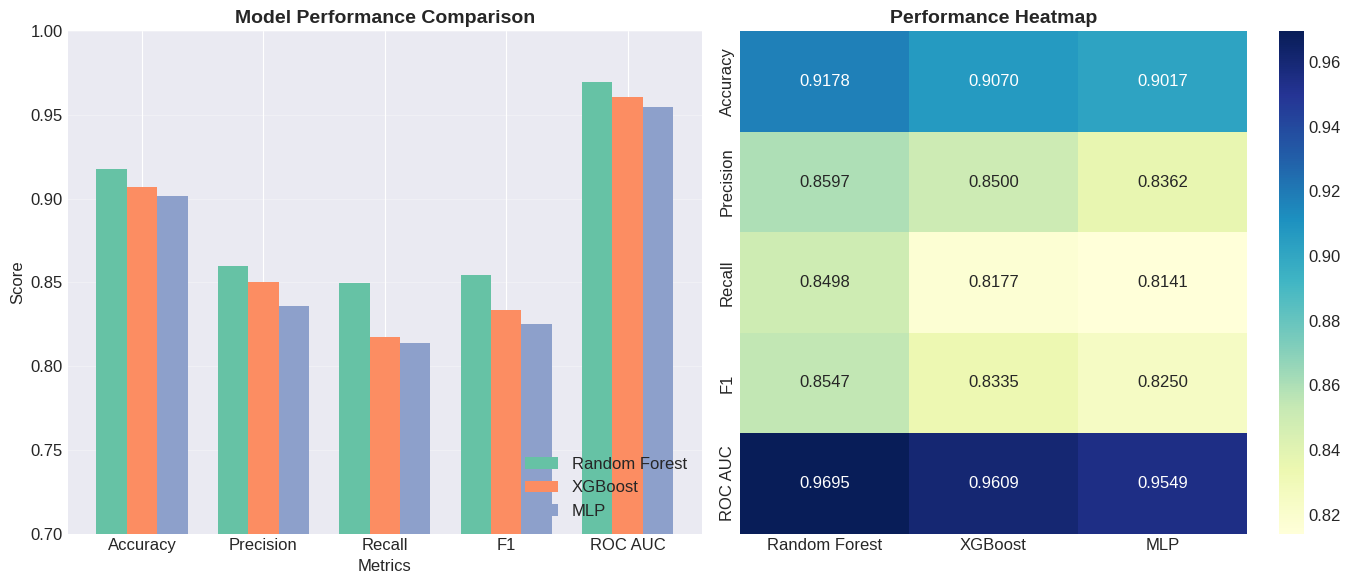

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Metrics to plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
models_list = results_df['Model'].tolist()

# Plot 1: Grouped bar chart
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(models_list):
    model_metrics = results_df[results_df['Model'] == model][metrics].values[0]
    offset = (i - 1) * width
    axes[0].bar(x + offset, model_metrics, width, label=model)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Heatmap of metrics
heatmap_data = results_df[metrics].T
heatmap_data.columns = models_list
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=models_list, yticklabels=metrics, ax=axes[1])
axes[1].set_title('Performance Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

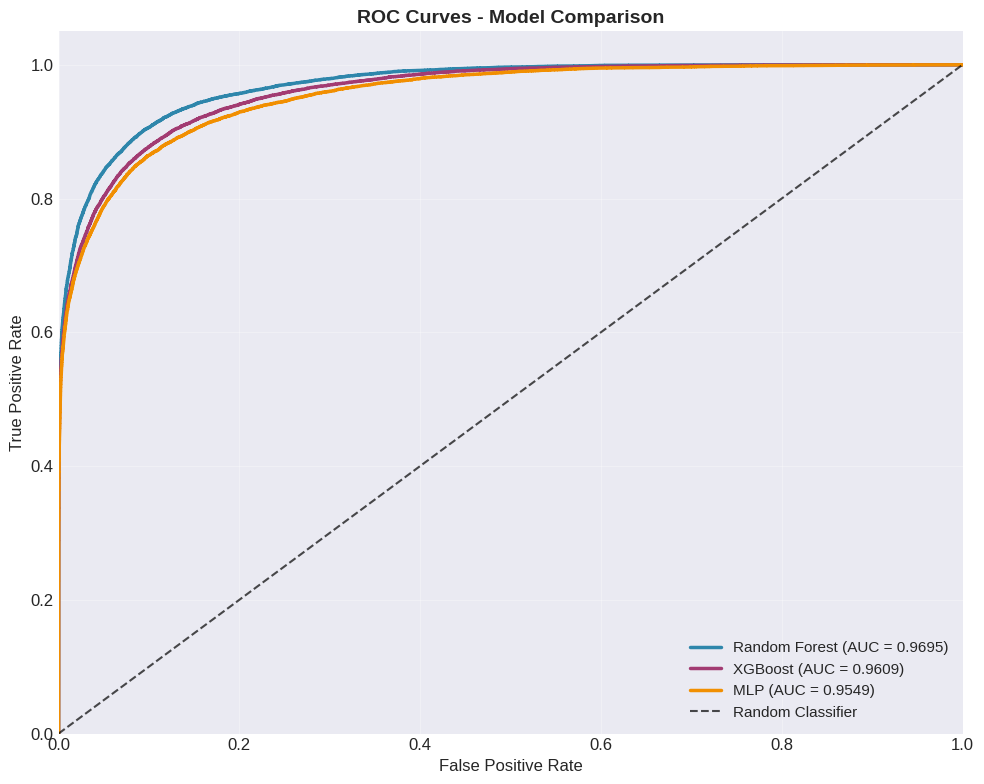

In [87]:

plt.figure(figsize=(10, 8))

colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, (name, model) in enumerate(models.items()):
    # Get predictions based on model type
    if name == "MLP":
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = results_df[results_df['Model'] == name]['ROC AUC'].values[0]

    plt.plot(fpr, tpr, color=colors[i], lw=2.5,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

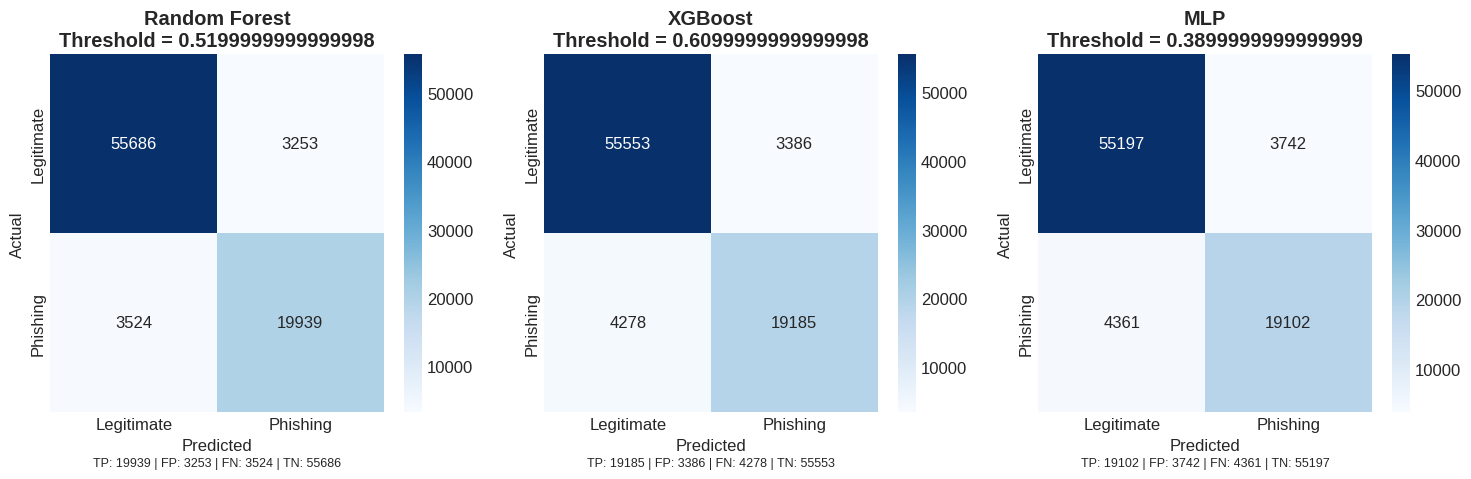

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, model) in enumerate(models.items()):
    # Get predictions with optimized threshold
    threshold = results_df[results_df['Model'] == name]['Threshold'].values[0]

    if name == "MLP":
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.predict_proba(X_test)[:, 1]

    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    axes[idx].set_title(f'{name}\nThreshold = {threshold}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    # Add annotations with metrics
    tn, fp, fn, tp = cm.ravel()
    axes[idx].text(0.5, -0.15, f'TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}',
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

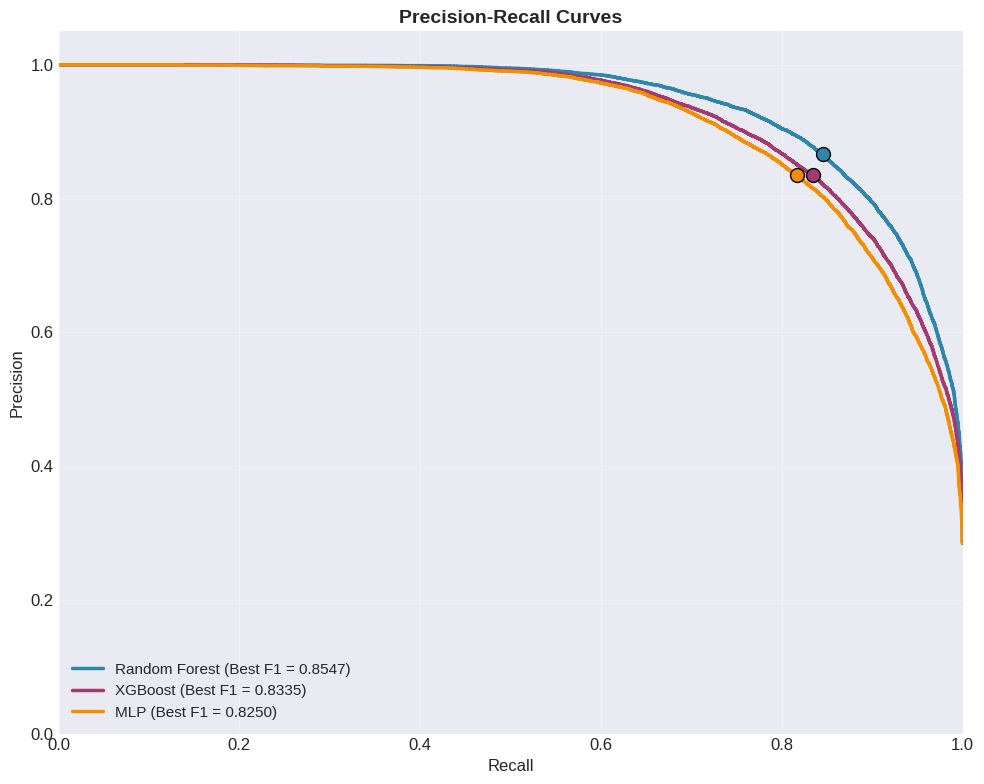

In [89]:

plt.figure(figsize=(10, 8))

for i, (name, model) in enumerate(models.items()):
    if name == "MLP":
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_f1_idx = np.argmax(f1_scores)

    plt.plot(recall, precision, color=colors[i], lw=2.5,
             label=f'{name} (Best F1 = {results_df[results_df["Model"] == name]["F1"].values[0]:.4f})')
    plt.scatter(recall[best_f1_idx], precision[best_f1_idx], color=colors[i],
                s=100, edgecolors='black', zorder=5)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('results/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

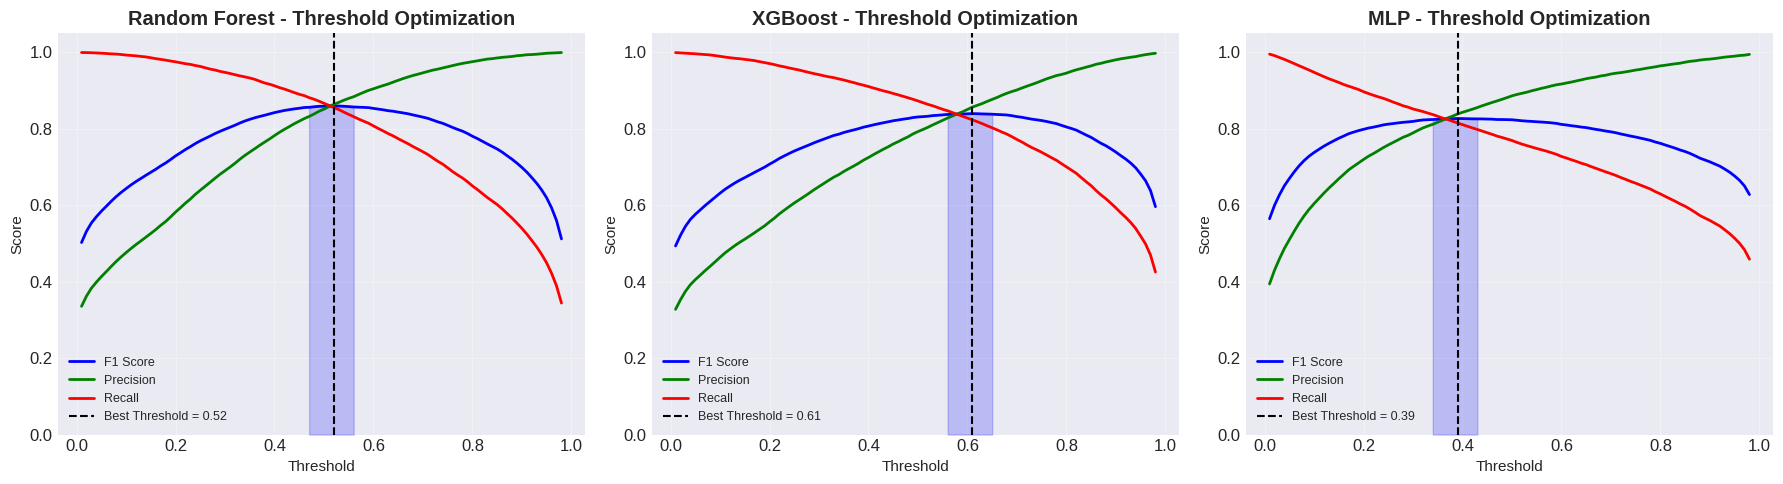

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Get validation probabilities
    if name == "MLP":
        val_probs = model.predict_proba(X_val_scaled)[:, 1]
    else:
        val_probs = model.predict_proba(X_val)[:, 1]

    thresholds = np.arange(0.01, 0.99, 0.01)
    f1_scores = []
    precisions = []
    recalls = []

    for t in thresholds:
        preds = (val_probs >= t).astype(int)
        f1_scores.append(f1_score(y_val, preds))
        precisions.append(precision_score(y_val, preds, zero_division=0))
        recalls.append(recall_score(y_val, preds))

    best_threshold = results_df[results_df['Model'] == name]['Threshold'].values[0]

    axes[idx].plot(thresholds, f1_scores, 'b-', label='F1 Score', lw=2)
    axes[idx].plot(thresholds, precisions, 'g-', label='Precision', lw=2)
    axes[idx].plot(thresholds, recalls, 'r-', label='Recall', lw=2)
    axes[idx].axvline(x=best_threshold, color='k', linestyle='--',
                      label=f'Best Threshold = {best_threshold:.2f}')
    axes[idx].fill_between(thresholds, 0, f1_scores, where=(thresholds >= best_threshold-0.05) &
                           (thresholds <= best_threshold+0.05), alpha=0.2, color='blue')

    axes[idx].set_xlabel('Threshold', fontsize=11)
    axes[idx].set_ylabel('Score', fontsize=11)
    axes[idx].set_title(f'{name} - Threshold Optimization', fontweight='bold')
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('results/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

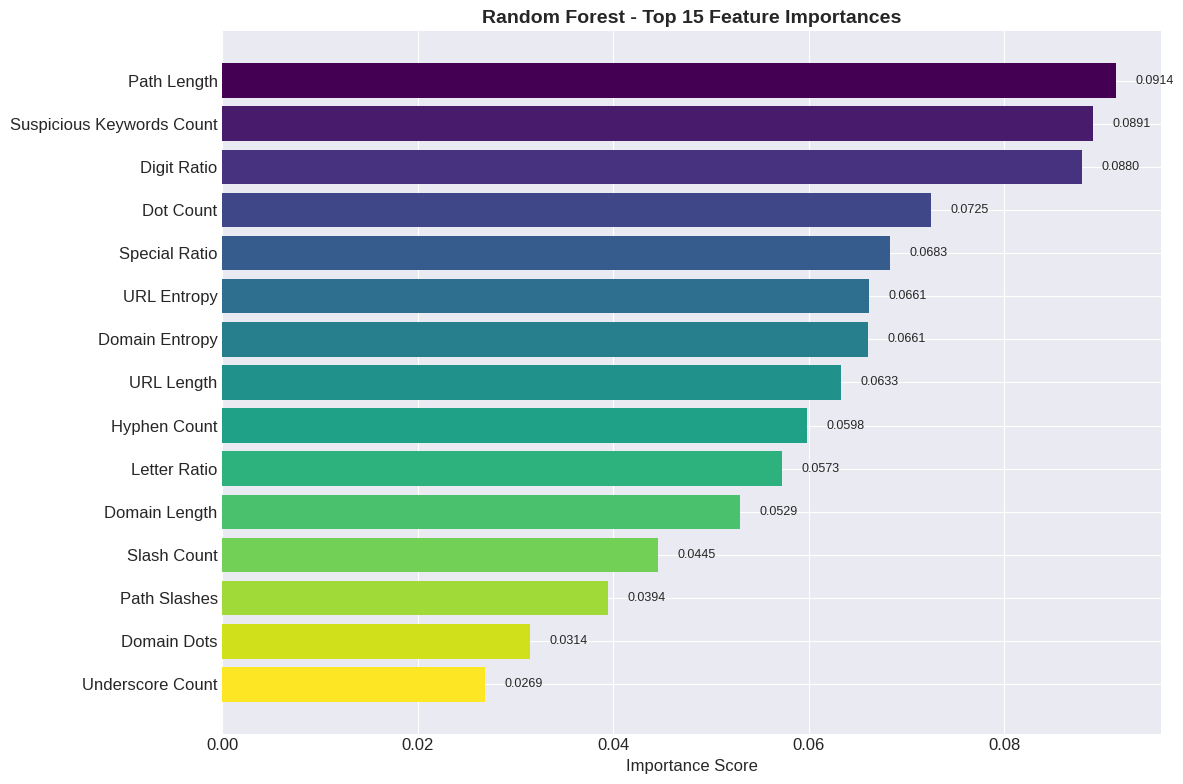

In [91]:

feature_names = [
    'URL Length', 'Domain Length', 'Path Length', 'Query Length',
    'Dot Count', 'Hyphen Count', 'Underscore Count', 'Slash Count',
    'Question Mark Count', 'Equal Count', 'At Sign Count', 'Ampersand Count',
    'Percent Count', 'Digit Ratio', 'Letter Ratio', 'Special Ratio',
    'Suspicious TLD', 'Has IP Address', 'Has Hyphen in Domain',
    'Suspicious Keywords Count', 'Domain Dots', 'Path Slashes',
    'Domain Entropy', 'URL Entropy'
]

rf_model = models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(12, 8))
colors_imp = plt.cm.viridis(np.linspace(0, 1, 15))
bars = plt.barh(range(15), importances[indices], color=colors_imp)
plt.yticks(range(15), [feature_names[i] for i in indices])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest - Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [93]:

print("\n" + "="*80)
print(" " * 20 + "FINAL MODEL EVALUATION SUMMARY")
print("="*80)

summary_table = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'Threshold']].copy()
summary_table = summary_table.round(4)
summary_table = summary_table.sort_values('F1', ascending=False)

# Add Best indicator
summary_table['Best'] = ['Best' if i == 0 else '' for i in range(len(summary_table))]

print(summary_table.to_string(index=False))

print("\n" + "="*80)
print(" RECOMMENDATION: Random Forest is the best model for deployment")
print(f" - Highest F1 Score: {summary_table.iloc[0]['F1']:.4f}")
print(f" - Highest ROC-AUC: {summary_table.iloc[0]['ROC AUC']:.4f}")
print(f" - Optimal Threshold: {summary_table.iloc[0]['Threshold']:.2f}")
print("="*80)

# Save summary to CSV
summary_table.to_csv('results/model_comparison_summary.csv', index=False)
print("\nAll visualizations saved to 'results/' directory")


                    FINAL MODEL EVALUATION SUMMARY
        Model  Accuracy  Precision  Recall     F1  ROC AUC  Threshold Best
Random Forest    0.9178     0.8597  0.8498 0.8547   0.9695       0.52 Best
      XGBoost    0.9070     0.8500  0.8177 0.8335   0.9609       0.61     
          MLP    0.9017     0.8362  0.8141 0.8250   0.9549       0.39     

 RECOMMENDATION: Random Forest is the best model for deployment
 - Highest F1 Score: 0.8547
 - Highest ROC-AUC: 0.9695
 - Optimal Threshold: 0.52

All visualizations saved to 'results/' directory
